In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [24]:
a = pd.read_csv("/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/ekg_20251230_160600.csv")

In [25]:
print(a.head())
print(a.columns)

   time_s  adc_raw  voltage
0  0.0000      426   1.3742
1  0.0141        0   0.0000
2  0.0184        0   0.0000
3  0.0228      912   2.9419
4  0.0271        0   0.0000
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


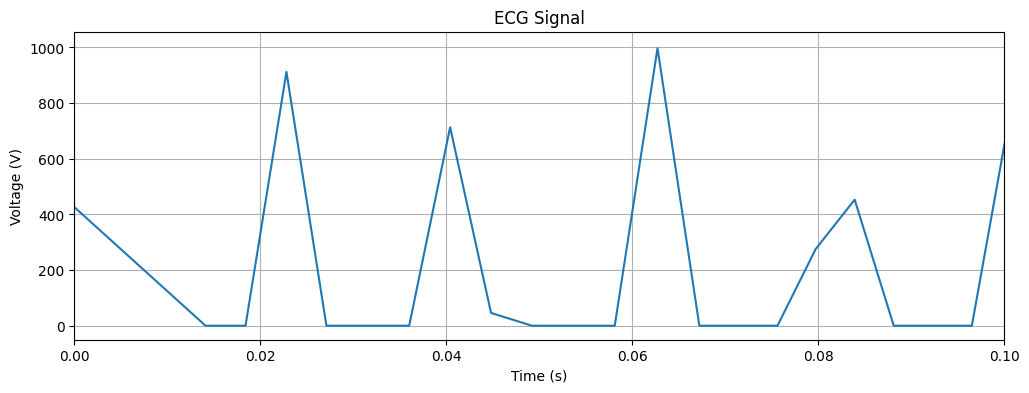

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(a['time_s'], a['adc_raw'])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.xlim(xmin=0, xmax=0.1)  # Adjust x-axis limits as needed
plt.title('ECG Signal')
plt.grid()
plt.show()

In [ ]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.signal import find_peaks, butter, filtfilt

csv_file = "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/ekg_20251230_160600.csv"
output_img = "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/ekg_plot.png"

os.makedirs(os.path.dirname(output_img), exist_ok=True)

time_date = []
voltage_data = []

with open(csv_file, 'r') as file:
    reader = csv.DictReader(file)
    for row in reader:
        time_date.append(row['time_s'])
        voltage_data.append(float(row['adc_raw']))

# Convert to numpy arrays
time_date = np.array(time_date, dtype=float)
voltage_data = np.array(voltage_data)

print("Jumlah Data:", len(time_date))
print("Tegangan Min-Max:", np.min(voltage_data), np.max(voltage_data))

voltage_data = voltage_data - np.mean(voltage_data)

fs = 250
lowcut = 0.5
highcut = 40.0

b, a = butter(4, [lowcut / (0.5 * fs), highcut / (0.5 * fs)], btype='band')
ekg_filtered = filtfilt(b, a, voltage_data)
treshold = 0.5 * np.max(ekg_filtered)

min_distance = int(0.2 * fs)

peaks, properties = find_peaks(ekg_filtered, height=treshold, distance=min_distance)

print("Jumlah Puncak Deteksi:", len(peaks))

rr_intervals = np.diff(peaks) / fs
print("R-R Intervals (s):", rr_intervals)

bpm = 60 / rr_intervals
print("BPM:", bpm)

print("Rata-rata BPM:", np.mean(bpm))

ekg_mV = ekg_filtered / np.max(np.abs(ekg_filtered)) * 1000

duration = 10
samples = int(duration * fs)

plt.figure(figsize=(12, 6))
plt.plot(time_date[:samples], ekg_mV[:samples], label='ECG Signal (mV)')
plt.plot(time_date[peaks], ekg_mV[peaks], 'ro', label='Detected R-peaks')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')

plt.ylim(-1500, 1500)
plt.xlim(time_date[0], time_date[0] + duration)

plt.grid(which='major', color='red', linewidth=0.5)
plt.minorticks_on()
plt.grid(which='minor', color='blue', linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.show()

print('Gambar tersimpan', output_img)